In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../dataset/retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
df.shape

(1000, 9)

In [3]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [12]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [13]:
df['Total Amount'].sum()

np.int64(456000)

In [14]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

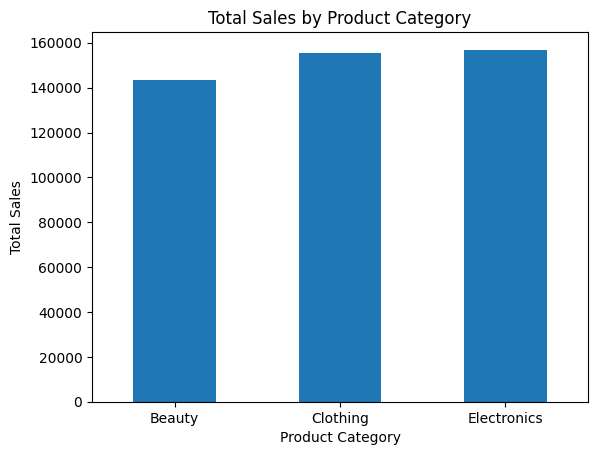

In [15]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [16]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

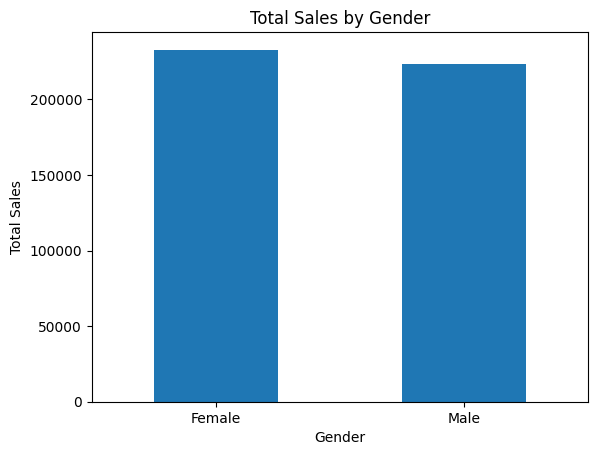

In [17]:
gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

In [18]:
quantity_category = df.groupby('Product Category')['Quantity'].sum()

quantity_category

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

In [20]:
df['Month'] = df['Date'].dt.month
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


In [21]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

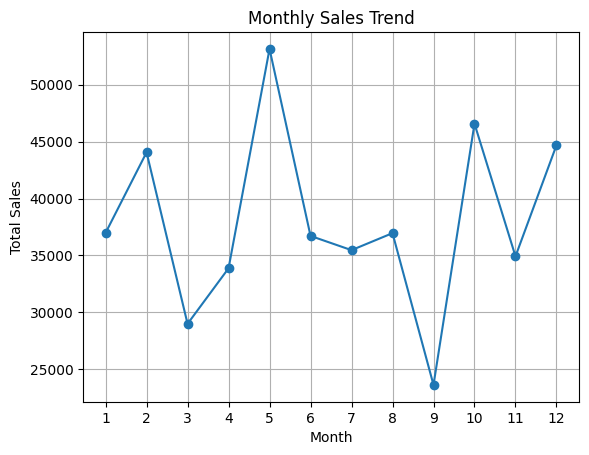

In [22]:
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.grid()
plt.show()

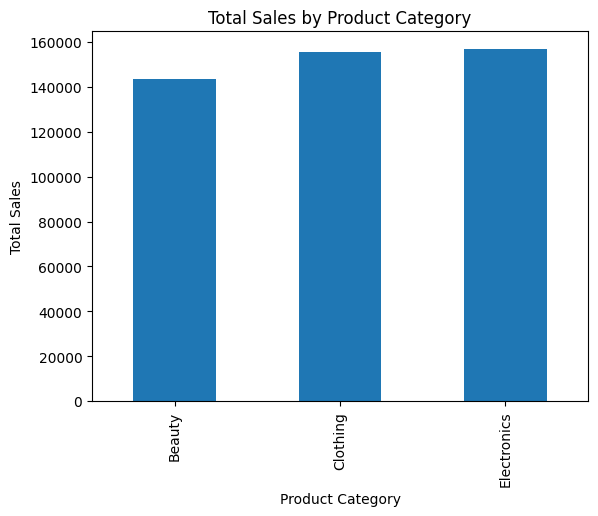

In [23]:
category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.savefig('../images/sales_by_category.png', bbox_inches='tight')

plt.show()

In [24]:
df.shape

(1000, 10)

In [25]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

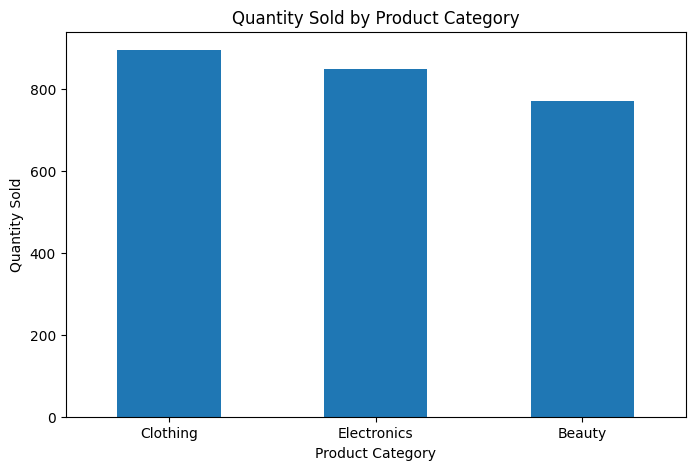

In [26]:
category_quantity.plot(kind='bar', figsize=(8,5))

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)

plt.savefig('../images/quantity_by_category.png', bbox_inches='tight')

plt.show()

In [27]:
gender_sales = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

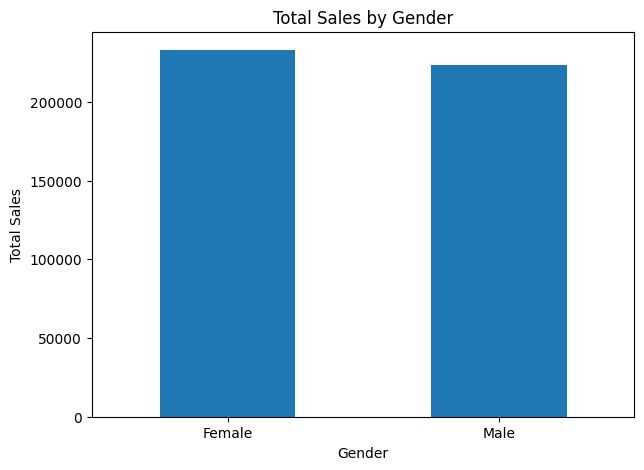

In [28]:
gender_sales.plot(kind='bar', figsize=(7,5))

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.savefig('../images/sales_by_gender.png', bbox_inches='tight')

plt.show()

In [29]:
gender_quantity = df.groupby('Gender')['Quantity'].sum()

gender_quantity

Gender
Female    1298
Male      1216
Name: Quantity, dtype: int64

In [30]:

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(5), object(3)
memory usage: 74.3+ KB


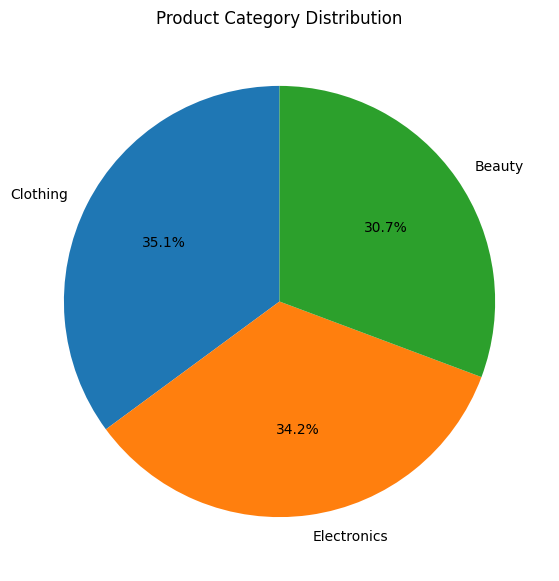

In [31]:
category_count = df['Product Category'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    category_count,
    labels=category_count.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Product Category Distribution')
plt.show()

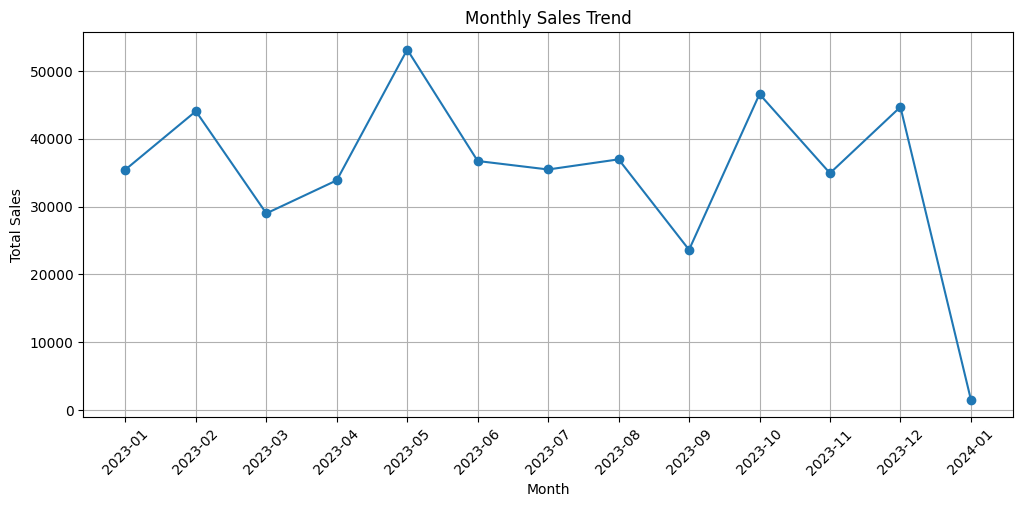

In [32]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

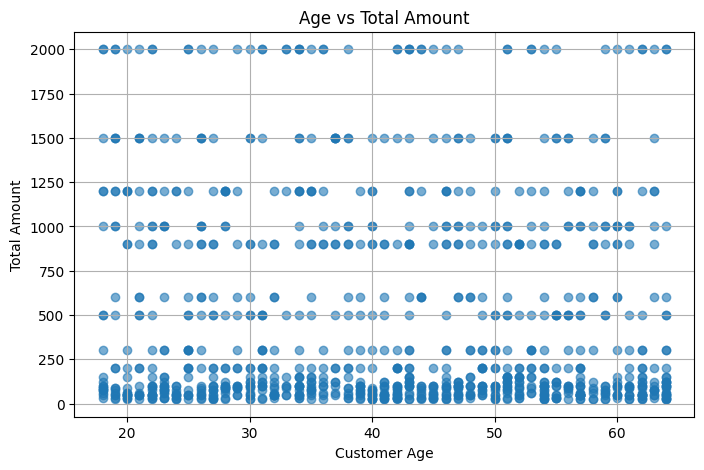

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Total Amount'], alpha=0.6)
plt.title('Age vs Total Amount')
plt.xlabel('Customer Age')
plt.ylabel('Total Amount')
plt.grid(True)
plt.show()

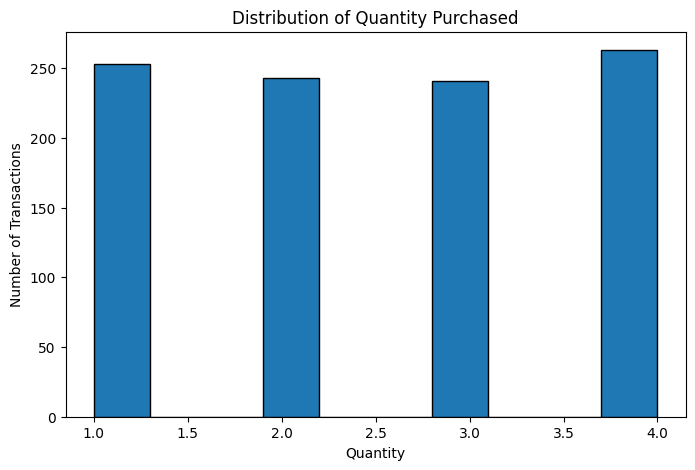

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=10, edgecolor='black')
plt.title('Distribution of Quantity Purchased')
plt.xlabel('Quantity')
plt.ylabel('Number of Transactions')
plt.show()

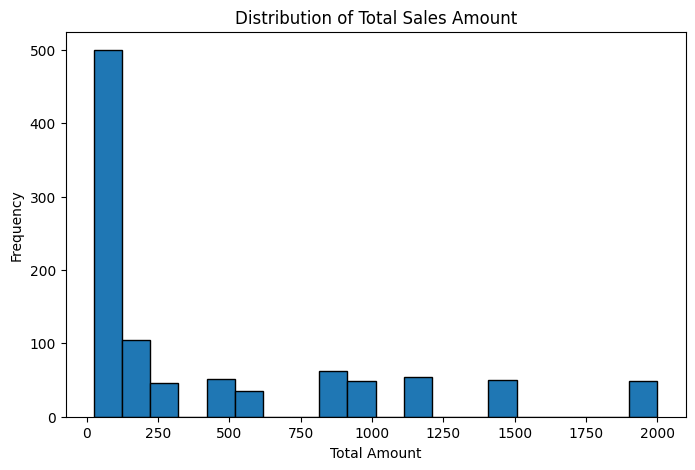

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df['Total Amount'], bins=20, edgecolor='black')
plt.title('Distribution of Total Sales Amount')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.show()

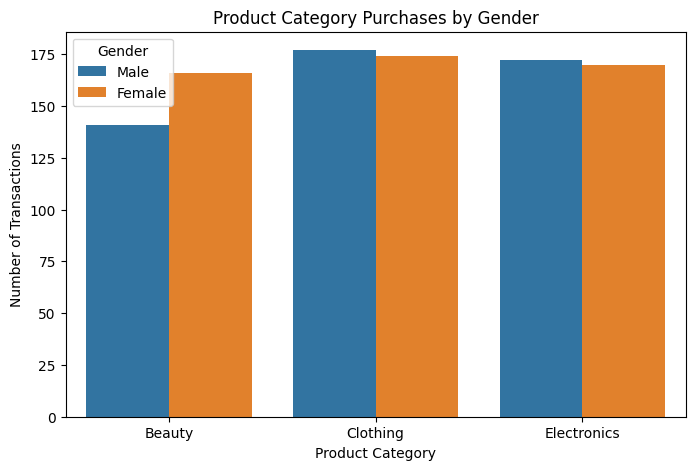

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Product Category', hue='Gender')
plt.title('Product Category Purchases by Gender')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

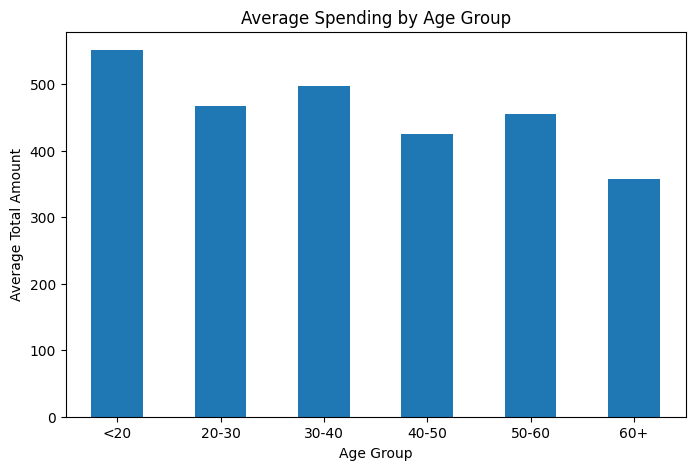

In [37]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+']
)

age_group_sales = df.groupby('Age Group', observed=False)['Total Amount'].mean()

plt.figure(figsize=(8,5))
age_group_sales.plot(kind='bar')
plt.title('Average Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=0)
plt.show()

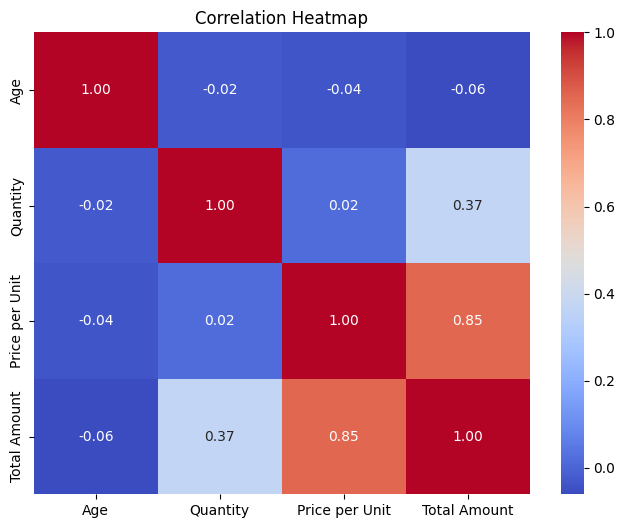

In [38]:
numeric_columns = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

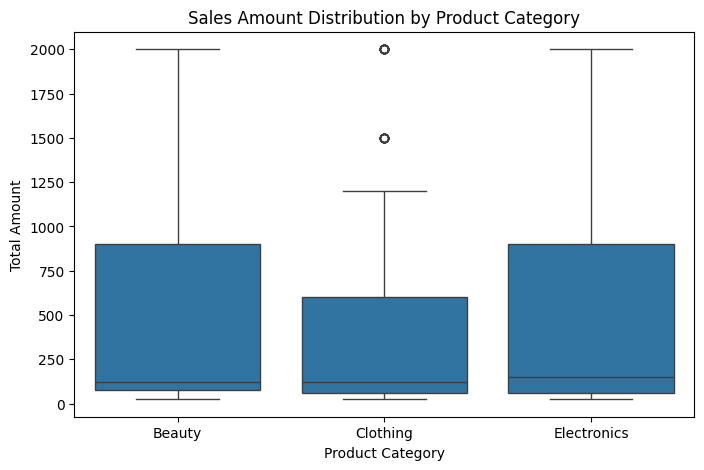

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Amount'
)

plt.title('Sales Amount Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.show()

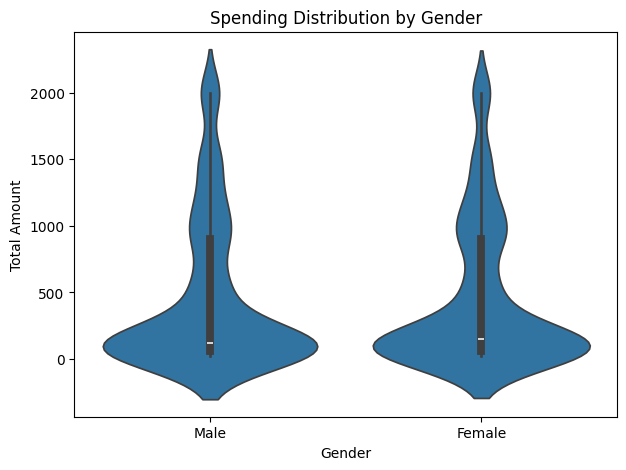

In [41]:
plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x='Gender',
    y='Total Amount'
)

plt.title('Spending Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()

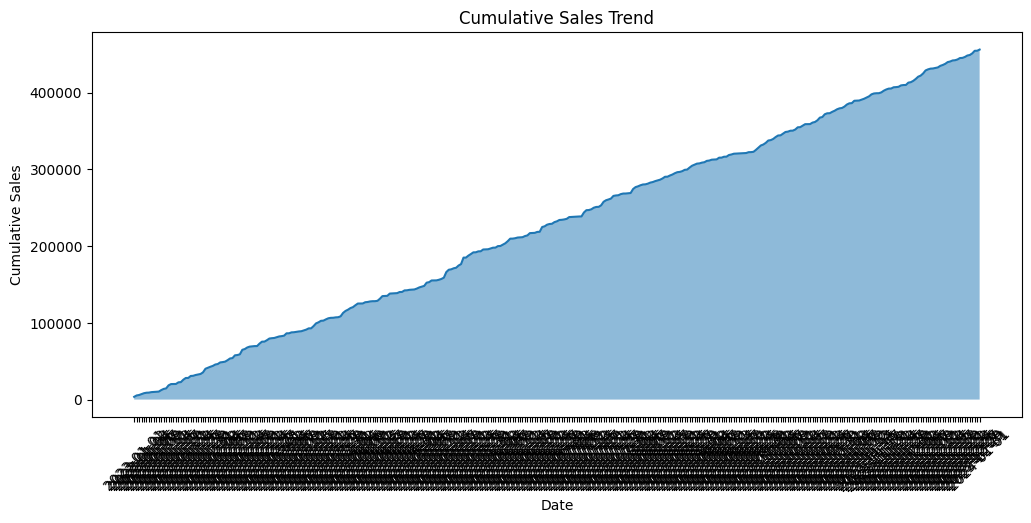

In [42]:
daily_sales = df.groupby('Date')['Total Amount'].sum().sort_index()
cumulative_sales = daily_sales.cumsum()

plt.figure(figsize=(12,5))

plt.fill_between(
    cumulative_sales.index,
    cumulative_sales.values,
    alpha=0.5
)

plt.plot(
    cumulative_sales.index,
    cumulative_sales.values
)

plt.title('Cumulative Sales Trend')
plt.xlabel('Date')
plt.ylabel('Cumulative Sales')
plt.xticks(rotation=45)
plt.show()

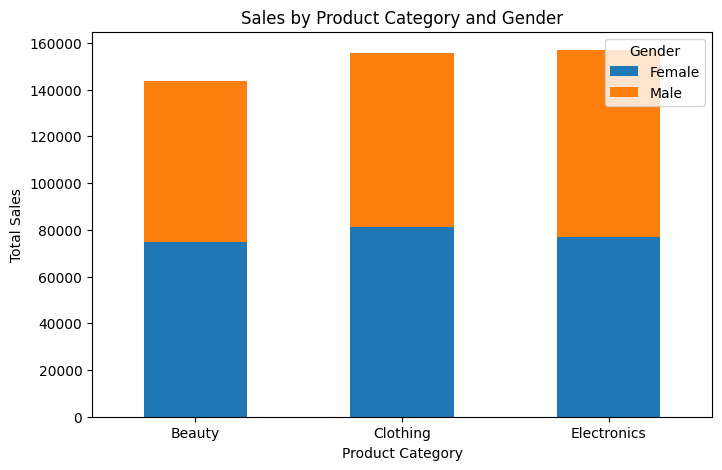

In [43]:
gender_category = pd.pivot_table(
    df,
    values='Total Amount',
    index='Product Category',
    columns='Gender',
    aggfunc='sum'
)

gender_category.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Sales by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.show()

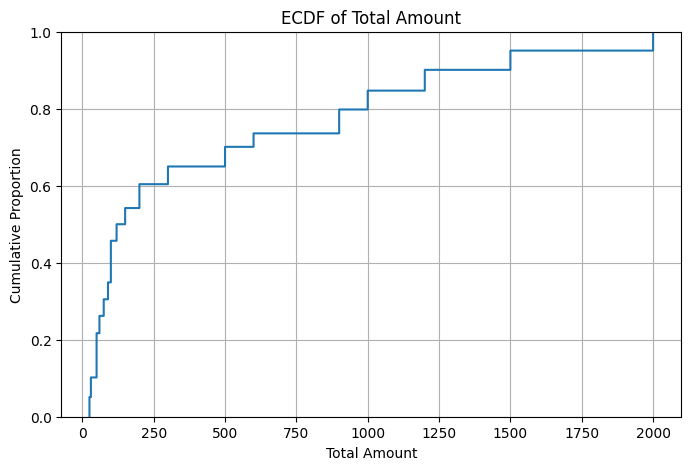

In [44]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df,
    x='Total Amount'
)

plt.title('ECDF of Total Amount')
plt.xlabel('Total Amount')
plt.ylabel('Cumulative Proportion')
plt.grid(True)
plt.show()

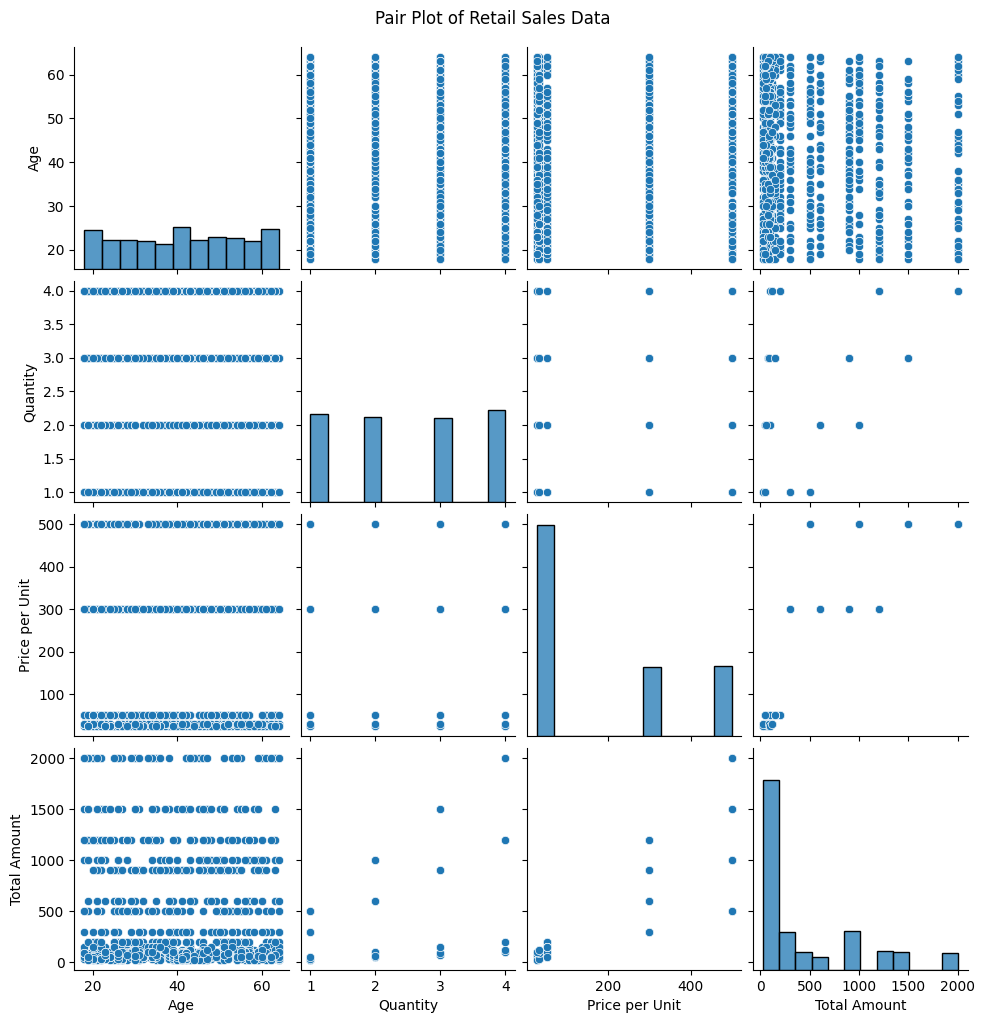

In [45]:
sns.pairplot(
    df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']],
    diag_kind='hist'
)

plt.suptitle('Pair Plot of Retail Sales Data', y=1.02)
plt.show()

In [48]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [50]:
df['Quarter'] = df['Date'].dt.quarter

quarterly_sales = (
    df.groupby('Quarter')['Total Amount']
    .sum()
)

quarterly_sales

Quarter
1    110030
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64

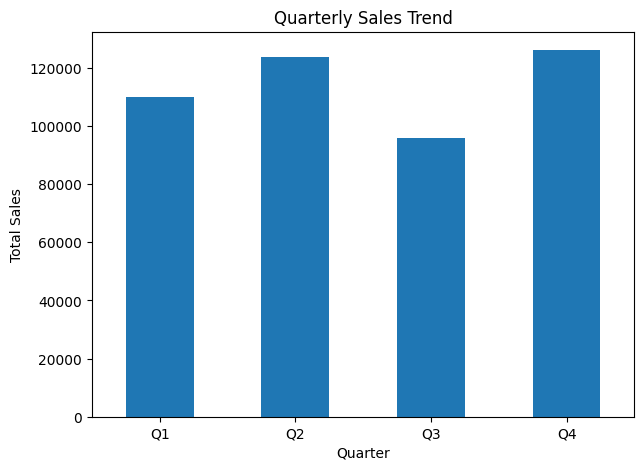

In [51]:
plt.figure(figsize=(7,5))

quarterly_sales.plot(
    kind='bar'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(
    range(4),
    ['Q1', 'Q2', 'Q3', 'Q4'],
    rotation=0
)

plt.show()

In [52]:
top_10_transactions = (
    df.sort_values(
        by='Total Amount',
        ascending=False
    )
    .head(10)
)

top_10_transactions[
    [
        'Transaction ID',
        'Customer ID',
        'Product Category',
        'Quantity',
        'Total Amount'
    ]
]

,Transaction ID,Customer ID,Product Category,Quantity,Total Amount
945,946,CUST946,Electronics,4,2000
71,72,CUST072,Electronics,4,2000
14,15,CUST015,Electronics,4,2000
576,577,CUST577,Beauty,4,2000
571,572,CUST572,Clothing,4,2000
268,269,CUST269,Clothing,4,2000
502,503,CUST503,Beauty,4,2000
926,927,CUST927,Electronics,4,2000
252,253,CUST253,Clothing,4,2000
546,547,CUST547,Clothing,4,2000


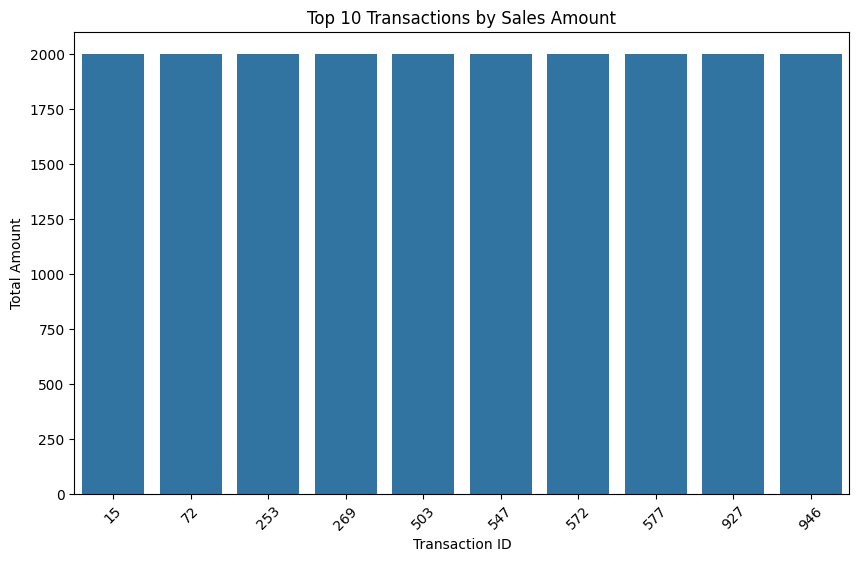

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_transactions,
    x='Transaction ID',
    y='Total Amount'
)

plt.title('Top 10 Transactions by Sales Amount')
plt.xlabel('Transaction ID')
plt.ylabel('Total Amount')

plt.xticks(rotation=45)

plt.show()

In [54]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=[
        'Under 20',
        '21-30',
        '31-40',
        '41-50',
        '51-60',
        '60+'
    ]
)

In [55]:
age_group_count = df['Age Group'].value_counts().sort_index()

age_group_count

Age Group
Under 20     63
21-30       210
31-40       193
41-50       221
51-60       220
60+          93
Name: count, dtype: int64

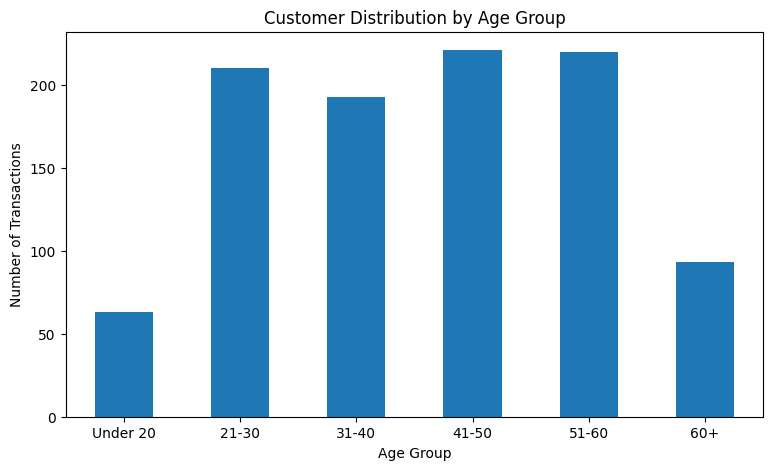

In [56]:
plt.figure(figsize=(9,5))

age_group_count.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)

plt.show()

In [57]:
age_group_sales = (
    df.groupby('Age Group', observed=True)['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

age_group_sales

Age Group
51-60       100085
21-30        98215
31-40        95950
41-50        93795
Under 20     34730
60+          33225
Name: Total Amount, dtype: int64

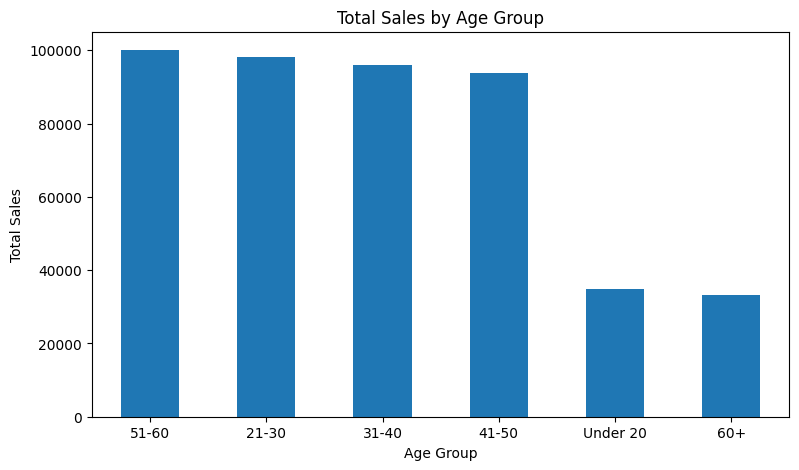

In [58]:
plt.figure(figsize=(9,5))

age_group_sales.plot(kind='bar')

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

In [60]:
gender_count = df['Gender'].value_counts()

gender_count

Gender
Female    510
Male      490
Name: count, dtype: int64

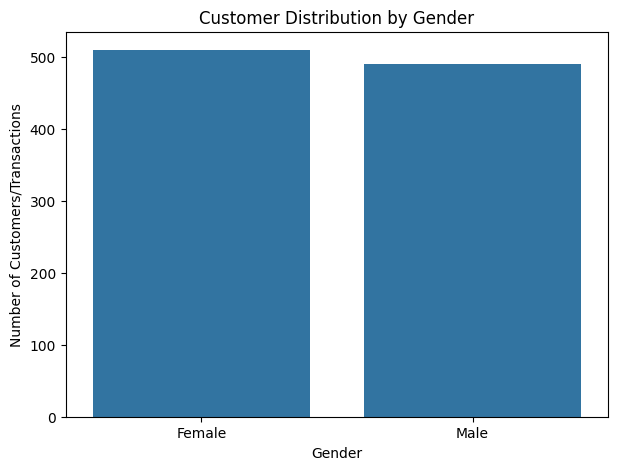

In [61]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values
)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers/Transactions')

plt.show()

In [62]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

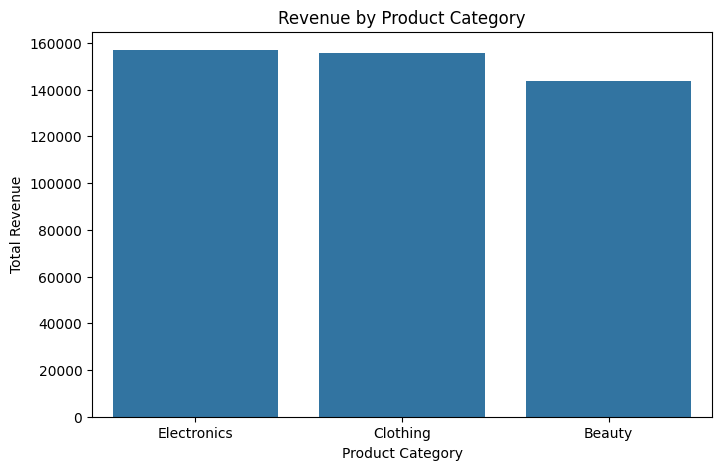

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.show()

In [64]:
numeric_columns = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation = df[numeric_columns].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


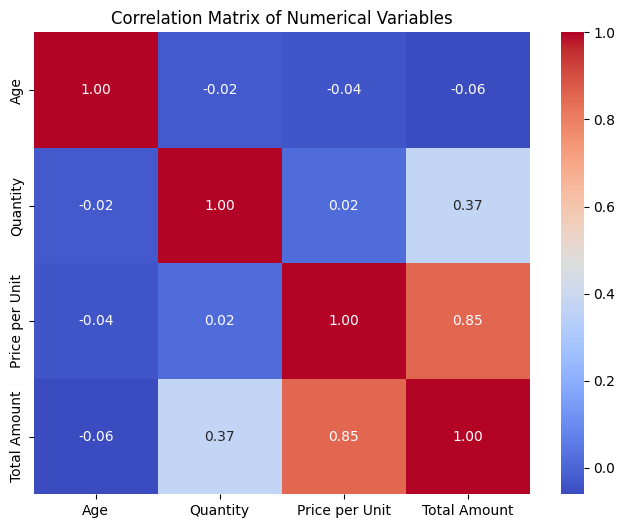

In [65]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

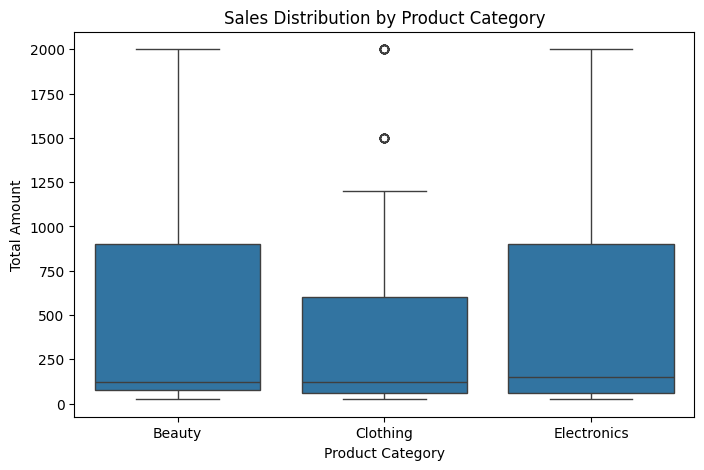

In [66]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Amount'
)

plt.title('Sales Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')

plt.show()

In [67]:
numeric_data = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
]

statistics_summary = pd.DataFrame({
    'Mean': numeric_data.mean(),
    'Median': numeric_data.median(),
    'Mode': numeric_data.mode().iloc[0],
    'Standard Deviation': numeric_data.std()
})

statistics_summary

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [68]:
total_revenue = df['Total Amount'].sum()
total_quantity = df['Quantity'].sum()
average_transaction = df['Total Amount'].mean()
unique_customers = df['Customer ID'].nunique()

print("Total Revenue:", total_revenue)
print("Total Quantity Sold:", total_quantity)
print("Average Transaction Value:", round(average_transaction, 2))
print("Unique Customers:", unique_customers)

Total Revenue: 456000
Total Quantity Sold: 2514
Average Transaction Value: 456.0
Unique Customers: 1000


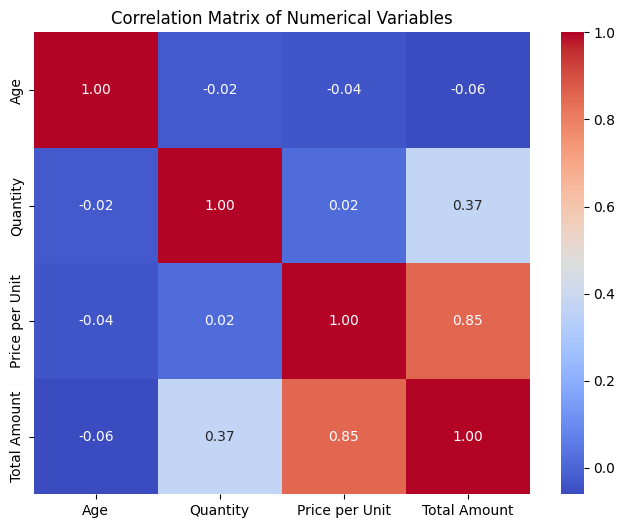

In [69]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

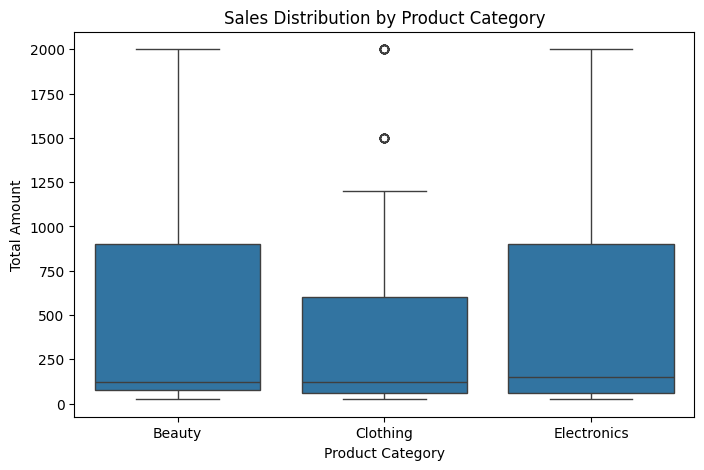

In [70]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Product Category',
    y='Total Amount'
)

plt.title('Sales Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')

plt.show()

In [71]:
avg_category_sales = (
    df.groupby('Product Category')['Total Amount']
    .mean()
    .sort_values(ascending=False)
)

avg_category_sales

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

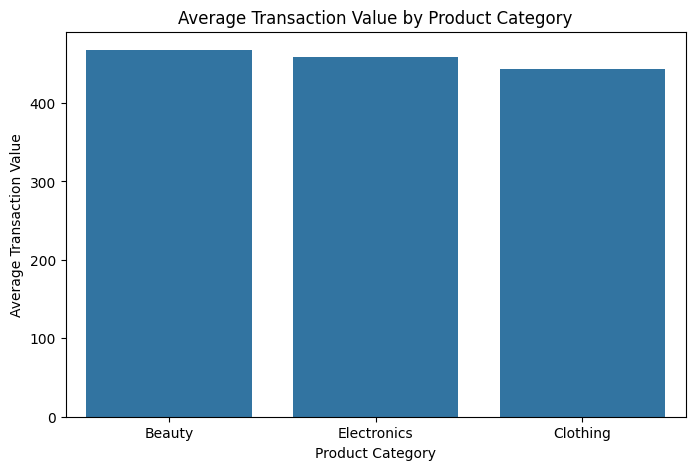

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_category_sales.index,
    y=avg_category_sales.values
)

plt.title('Average Transaction Value by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Transaction Value')

plt.show()

In [73]:
customer_spending = (
    df.groupby('Customer ID')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

customer_spending.head(10)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

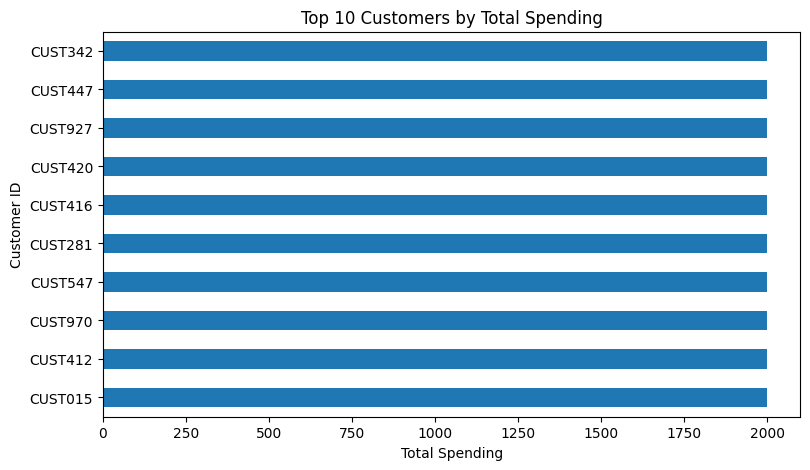

In [74]:
plt.figure(figsize=(9,5))

customer_spending.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Customer ID')

plt.show()

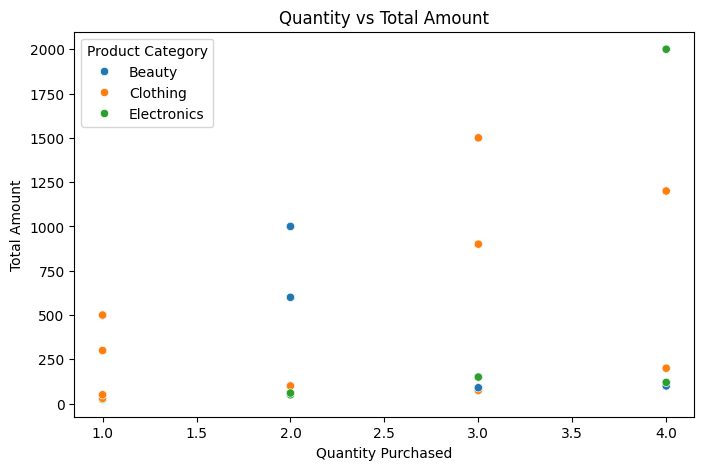

In [75]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Amount',
    hue='Product Category'
)

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity Purchased')
plt.ylabel('Total Amount')

plt.show()

In [76]:
category_gender_sales = pd.pivot_table(
    df,
    values='Total Amount',
    index='Product Category',
    columns='Gender',
    aggfunc='sum'
)

category_gender_sales

Gender,Female,Male
Product Category,,
Beauty,74830,68685
Clothing,81275,74305
Electronics,76735,80170


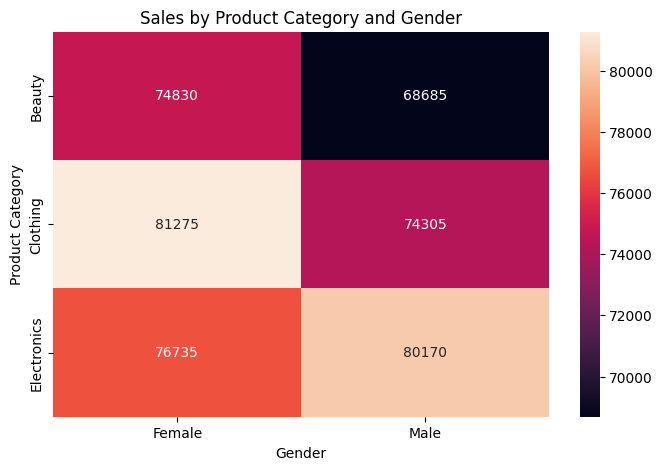

In [77]:
plt.figure(figsize=(8,5))

sns.heatmap(
    category_gender_sales,
    annot=True,
    fmt='.0f'
)

plt.title('Sales by Product Category and Gender')
plt.xlabel('Gender')
plt.ylabel('Product Category')

plt.show()

In [78]:
numeric_data = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
]

statistics_summary = pd.DataFrame({
    'Mean': numeric_data.mean(),
    'Median': numeric_data.median(),
    'Mode': numeric_data.mode().iloc[0],
    'Standard Deviation': numeric_data.std()
})

statistics_summary

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [79]:
total_revenue = df['Total Amount'].sum()
total_quantity = df['Quantity'].sum()
average_transaction = df['Total Amount'].mean()
unique_customers = df['Customer ID'].nunique()

print("Total Revenue:", total_revenue)
print("Total Quantity Sold:", total_quantity)
print("Average Transaction Value:", round(average_transaction, 2))
print("Unique Customers:", unique_customers)

Total Revenue: 456000
Total Quantity Sold: 2514
Average Transaction Value: 456.0
Unique Customers: 1000
